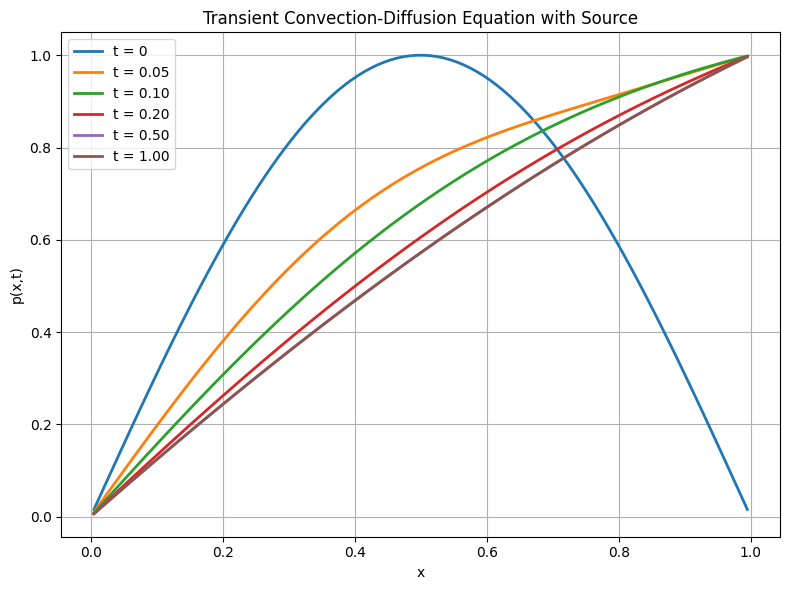

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import *

# ============================================================
# PARAMETERS
# ============================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

D = 1.0          # Diffusion coefficient
v = 0.5          # Drift velocity
S = 1.0          # Constant source

dt = 1e-4
final_time = 1.0
steps = int(final_time / dt)

# ============================================================
# VARIABLE
# ============================================================

p = CellVariable(name="Carrier Concentration", mesh=mesh)

x = mesh.cellCenters[0]

# Initial condition
p.setValue(np.sin(np.pi * x / L))

# ============================================================
# DIRICHLET BOUNDARY CONDITIONS
# ============================================================

p.constrain(0.0, mesh.facesLeft)
p.constrain(1.0, mesh.facesRight)

# ============================================================
# PDE
#
# ∂p/∂t = D∂²p/∂x² - v∂p/∂x + S
# ============================================================

eq = (
    TransientTerm()
    == DiffusionTerm(coeff=D)
    - PowerLawConvectionTerm(coeff=(v,))
    + S
)

# ============================================================
# PLOT SETTINGS
# ============================================================

plot_times = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]
plot_steps = [int(t / dt) for t in plot_times]

plt.figure(figsize=(8,6))

plt.plot(x.value, p.value,
         linewidth=2,
         label="t = 0")

# ============================================================
# TIME LOOP
# ============================================================

for step in range(1, steps + 1):

    eq.solve(var=p, dt=dt)

    if step in plot_steps:

        plt.plot(
            x.value,
            p.value,
            linewidth=2,
            label=f"t = {step*dt:.2f}"
        )

# ============================================================
# PLOT
# ============================================================

plt.xlabel("x")
plt.ylabel("p(x,t)")
plt.title("Transient Convection-Diffusion Equation with Source")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Maximum Error = 1.250146e-05
L2 Error      = 1.248341e-05


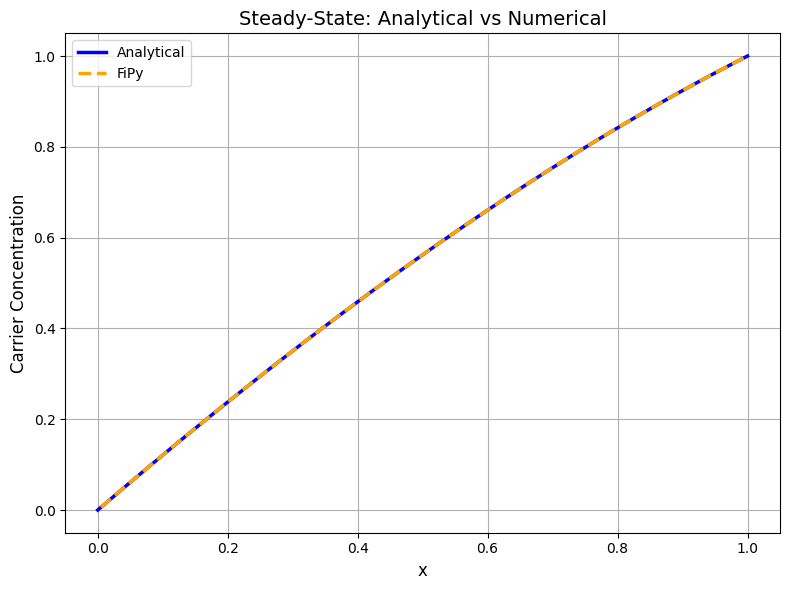

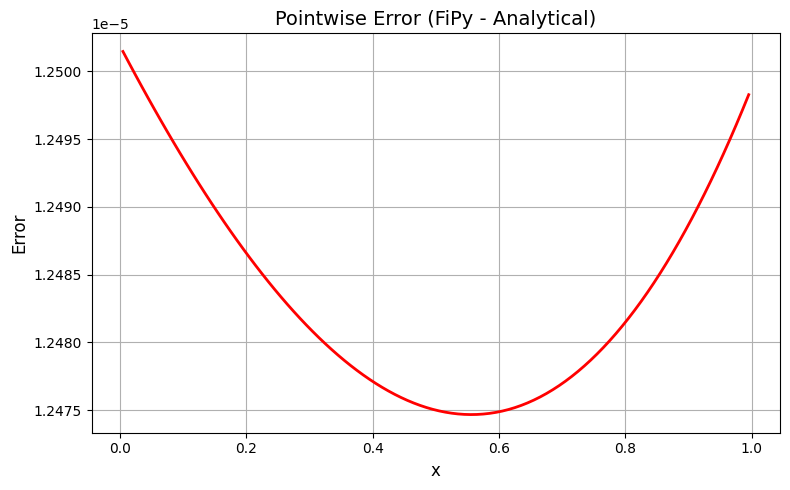

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import *

# ============================================================
# PARAMETERS
# ============================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

D = 1.0          # Diffusion coefficient
v = 0.5          # Drift velocity
S = 1.0          # Constant source

# ============================================================
# VARIABLE
# ============================================================

p = CellVariable(name="Carrier Concentration", mesh=mesh)

x = mesh.cellCenters[0]

# Initial guess
p.setValue(0.0)

# ============================================================
# DIRICHLET BOUNDARY CONDITIONS
# ============================================================

p.constrain(0.0, mesh.facesLeft)
p.constrain(1.0, mesh.facesRight)

# ============================================================
# STEADY-STATE PDE
#
# D d²p/dx² - v dp/dx + S = 0
# ============================================================

eq = (
    DiffusionTerm(coeff=D)
    - PowerLawConvectionTerm(coeff=(v,))
    + S
)

# Solve steady-state problem
eq.solve(var=p)

# ============================================================
# ANALYTICAL SOLUTION
# ============================================================

x_exact = np.linspace(0, L, 500)

C2 = (1.0 - (S * L / v)) / (np.exp(v * L / D) - 1.0)

p_exact = (
    (S / v) * x_exact
    + C2 * (np.exp(v * x_exact / D) - 1.0)
)

# ============================================================
# ANALYTICAL ON FIPY MESH
# ============================================================

x_num = x.value
p_num = p.value

p_exact_mesh = (
    (S / v) * x_num
    + C2 * (np.exp(v * x_num / D) - 1.0)
)

# ============================================================
# ERROR
# ============================================================

error = p_num - p_exact_mesh

max_error = np.max(np.abs(error))
l2_error = np.sqrt(np.mean(error**2))

print(f"Maximum Error = {max_error:.6e}")
print(f"L2 Error      = {l2_error:.6e}")

# ============================================================
# PLOT : ANALYTICAL VS NUMERICAL
# ============================================================

plt.figure(figsize=(8,6))

# Analytical (Blue Solid)
plt.plot(
    x_exact,
    p_exact,
    color='blue',
    linewidth=2.5,
    label='Analytical'
)

# FiPy (Orange Dashed)
plt.plot(
    x_num,
    p_num,
    '--',
    color='orange',
    linewidth=2.5,
    label='FiPy'
)

plt.xlabel("x", fontsize=12)
plt.ylabel("Carrier Concentration", fontsize=12)
plt.title("Steady-State: Analytical vs Numerical", fontsize=14)

plt.grid(True)
plt.legend()

plt.tight_layout()

# ============================================================
# ERROR PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    x_num,
    error,
    color='red',
    linewidth=2
)

plt.xlabel("x", fontsize=12)
plt.ylabel("Error", fontsize=12)
plt.title("Pointwise Error (FiPy - Analytical)", fontsize=14)

plt.grid(True)

plt.tight_layout()
plt.show()